[2026-07-24 23:24:30] [info     ] local test V3_3_resid_label 2024-01-01 ~ 2024-12-31
[2026-07-24 23:24:30] [info     ] training window: 2022-12-31 ~ 2023-12-31
[2026-07-24 23:24:30] [info     ] build_features 2022-12-31 ~ 2023-12-31 need_label=True


[2026-07-24 23:26:20] [info     ] bar features rows=574728 t=109.7s
[2026-07-24 23:26:36] [info     ] features done rows=241631 features=31 t=126.5s
[2026-07-24 23:27:13] [info     ] residualized training label rows=240609 controls=19 t=37.0s
[2026-07-24 23:27:14] [info     ] fit rows=191679 valid rows=47931 valid_start=2023-10-24 features=31
[2026-07-24 23:44:29] [info     ] model done best_iteration=158 raw_label_ic_mean=0.082401 raw_label_ic_ir=0.7547 residual_label_ic_mean=0.059887 residual_label_ic_ir=1.1628
[2026-07-24 23:44:37] [info     ] residualized against factor_pool rows=47931 controls=20 t=7.6s
[2026-07-24 23:44:37] [info     ] residual valid_ic_mean=0.068918 valid_ic_ir=1.0187
[2026-07-24 23:44:37] [info     ] build_features 2024-01-01 ~ 2024-12-31 need_label=False
[2026-07-24 23:46:00] [info     ] bar features rows=578929 t=82.5s
[2026-07-24 23:46:11] [info     ] features done rows=240771 features=31 t=93.6s
[2026-07-24 23:46:50] [info     ] residualized against factor_

时段,IC
2024-01-15~2024-02-08,-0.0013
2024-09-24~2024-10-08,0.0321

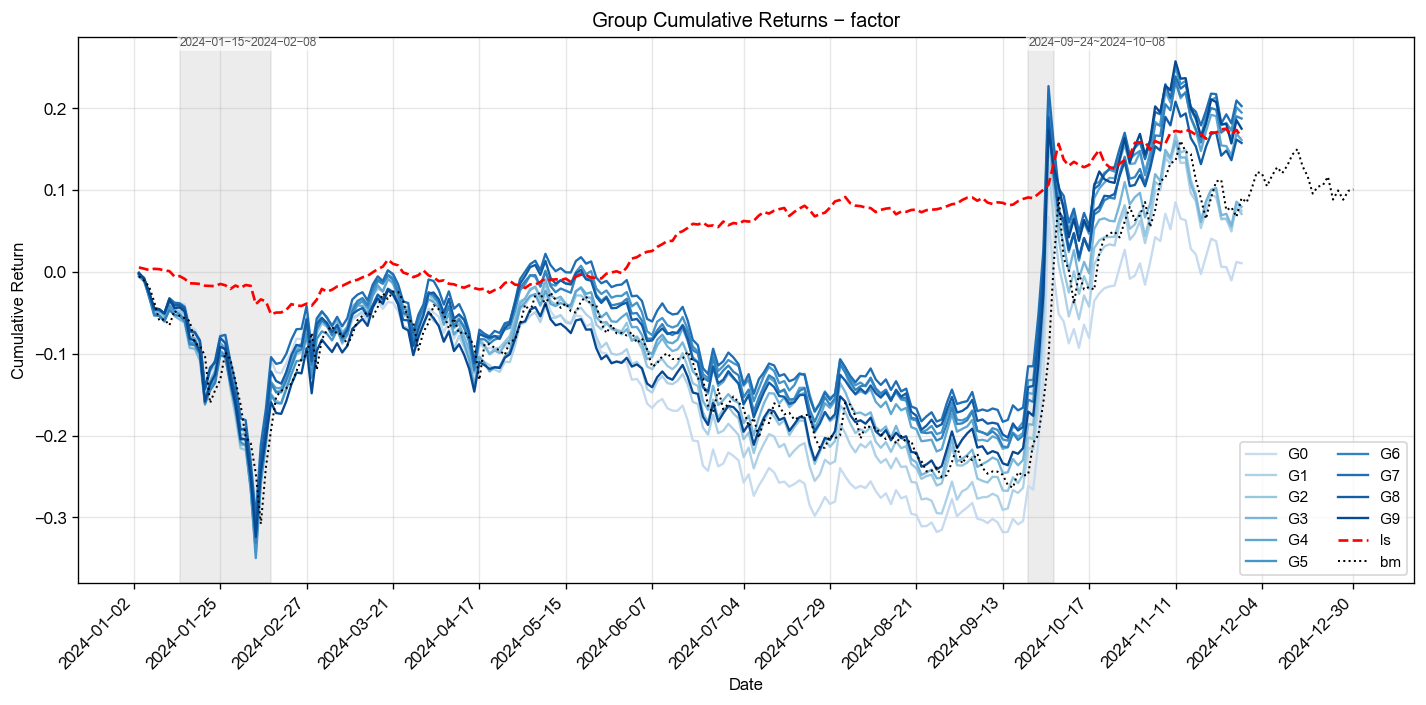
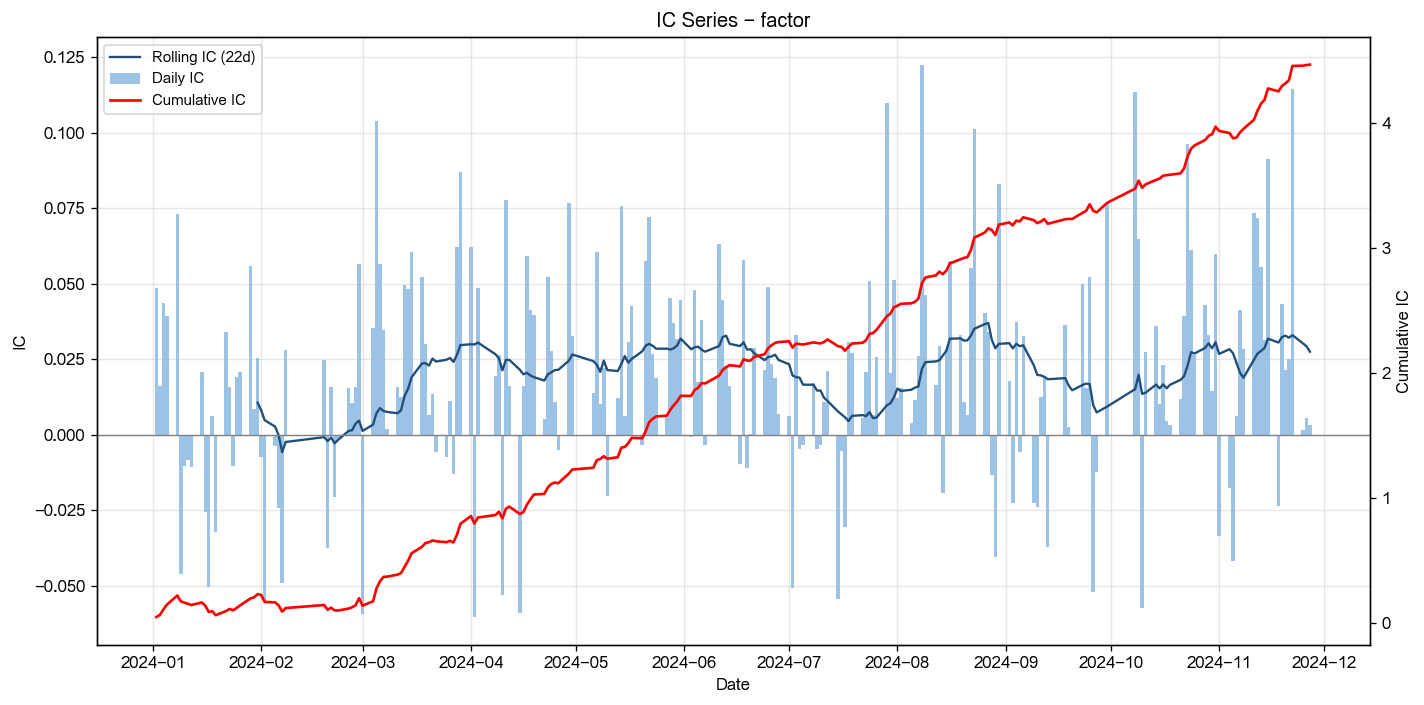
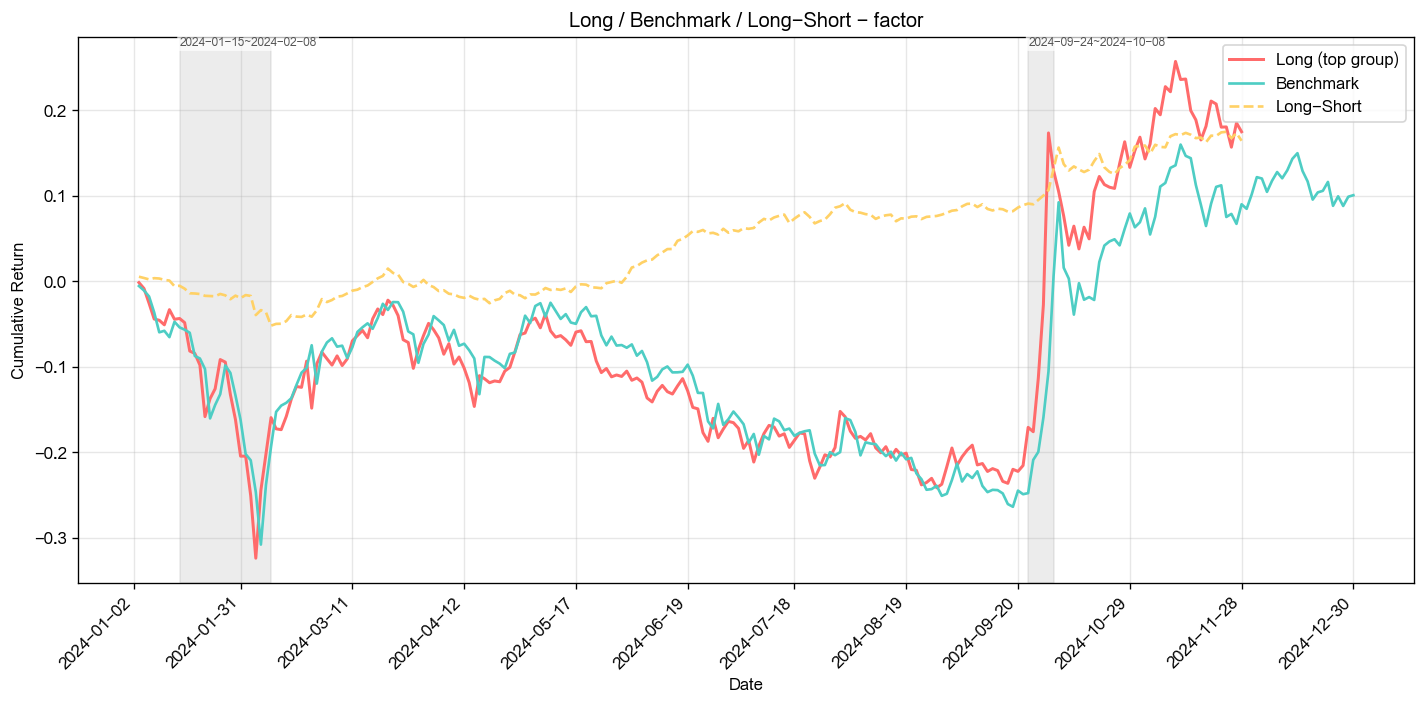
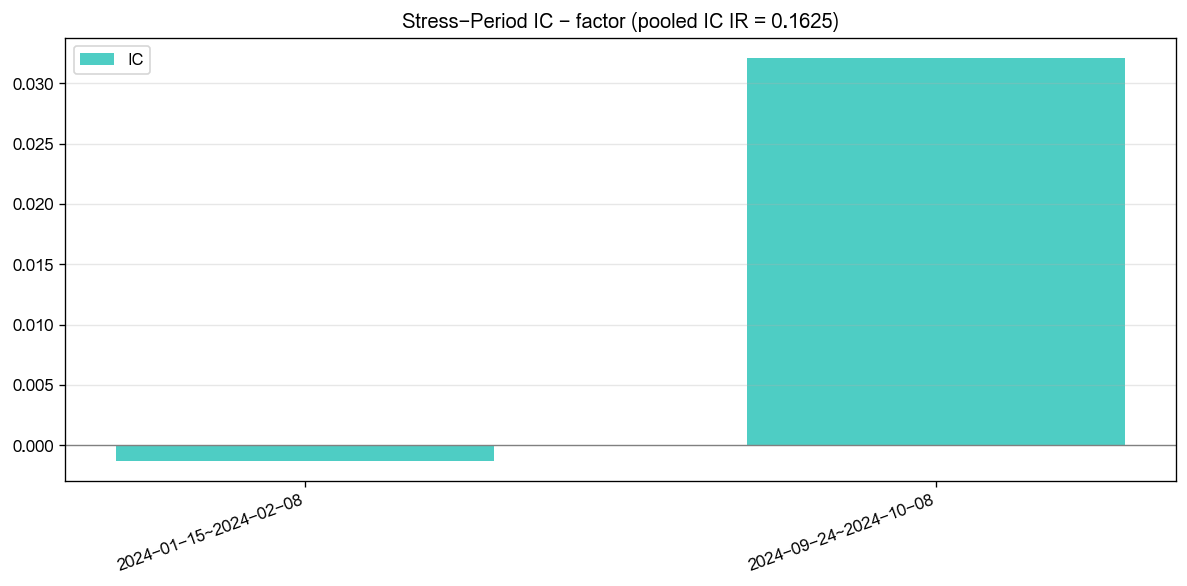
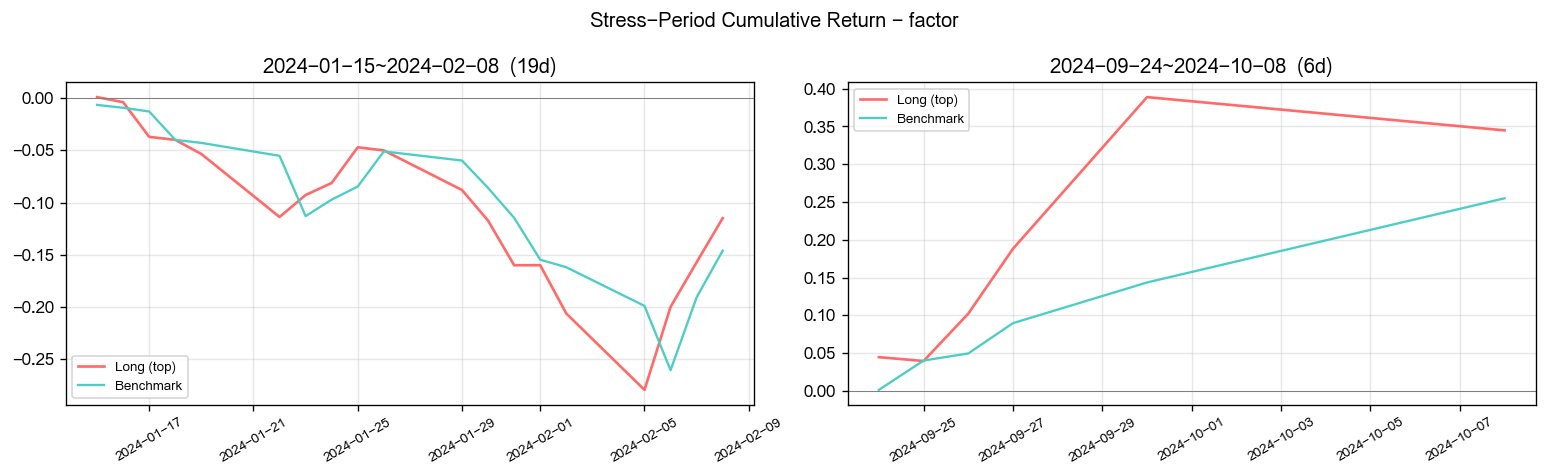

[2026-07-24 23:48:15] [info     ] ========== 因子池回归 ==========
[2026-07-24 23:48:15] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-30 instrument_count=1206 rows=296765 start_date=2024-01-02
[2026-07-24 23:48:16] [info     ] 获取收益率数据, 耗时: 1.4931 秒
[2026-07-24 23:48:18] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.9859 秒
[2026-07-24 23:48:18] [info     ] 统计 回归结果, 耗时: 0.0103 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.7032,0.0188,0.0070,1.0000
2,rsi_12,1.9412,0.0444,0.0229,1.0000
3,amount,1.7509,0.0181,0.0103,0.9000
4,gross_profit_rate_ttm,1.5314,0.0068,0.0045,1.0000
5,netflow_amount_rate_main,1.4773,0.0099,0.0067,1.0000
6,netflow_amount_main,1.4635,0.0245,0.0167,1.0000
7,net_profit_rate_ttm,1.4617,0.0039,0.0027,0.8000
8,cci_14,1.4582,0.0341,0.0234,1.0000
9,pb,1.4377,0.0097,0.0068,1.0000
10,bias_20,1.3634,0.0280,0.0206,0.9000

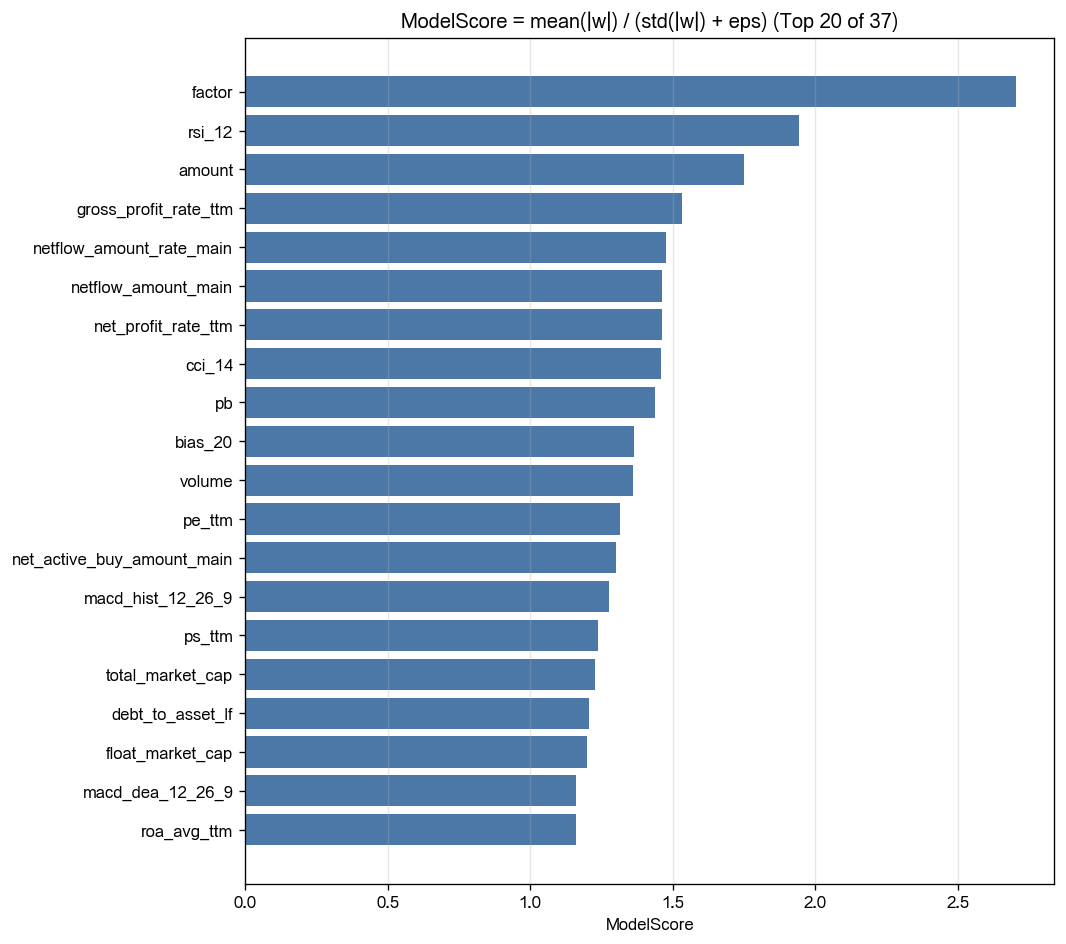
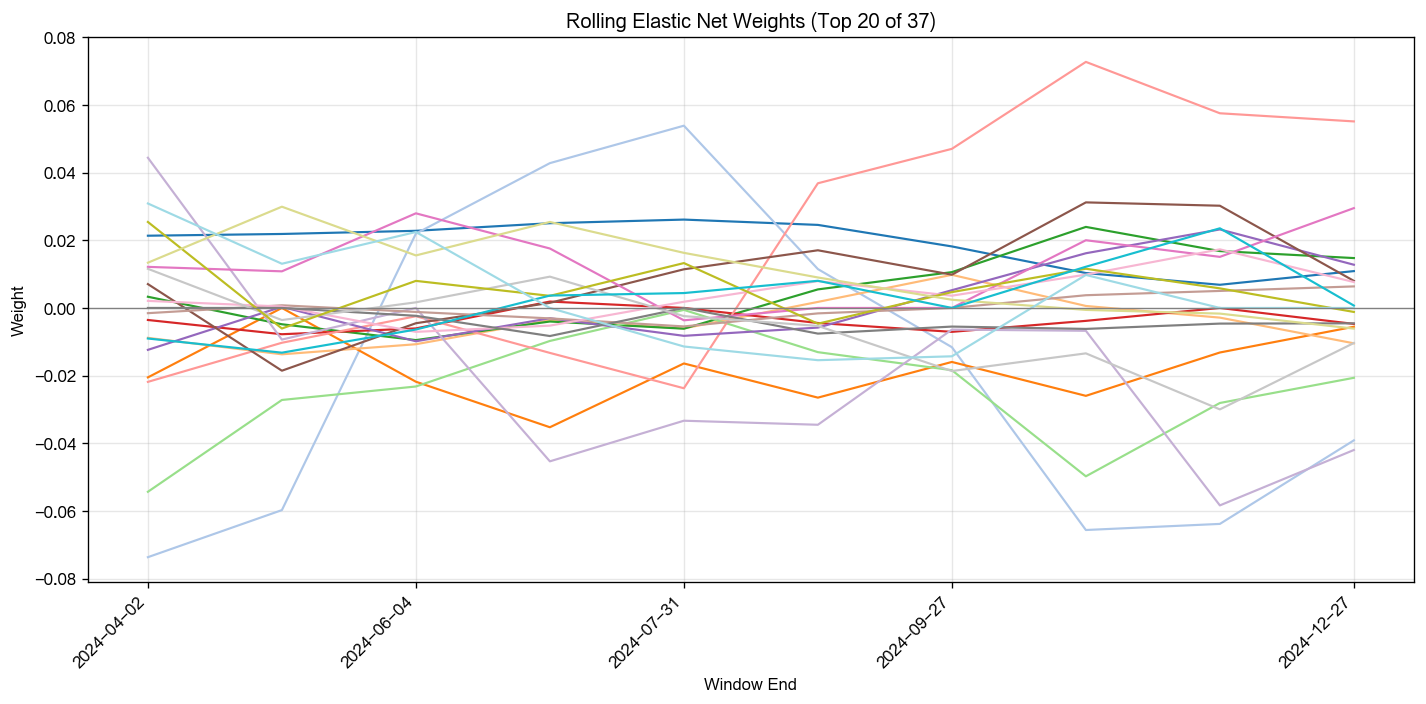
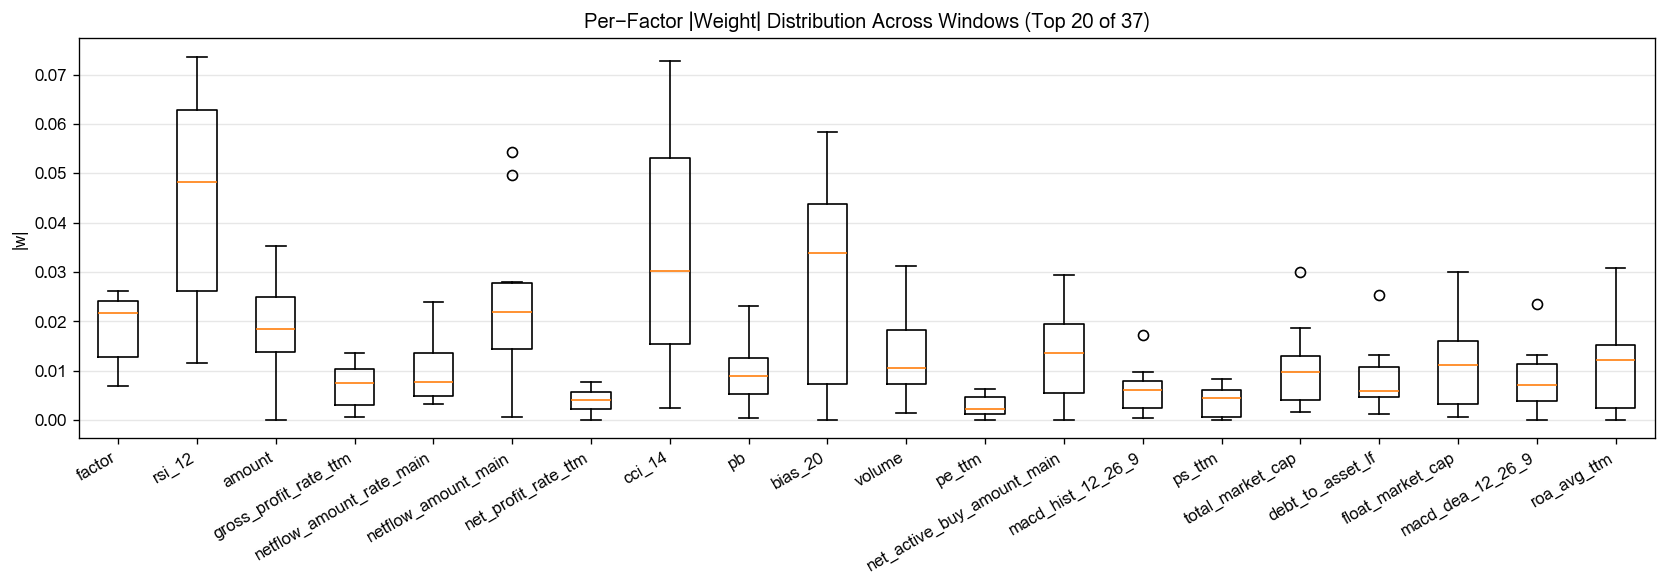
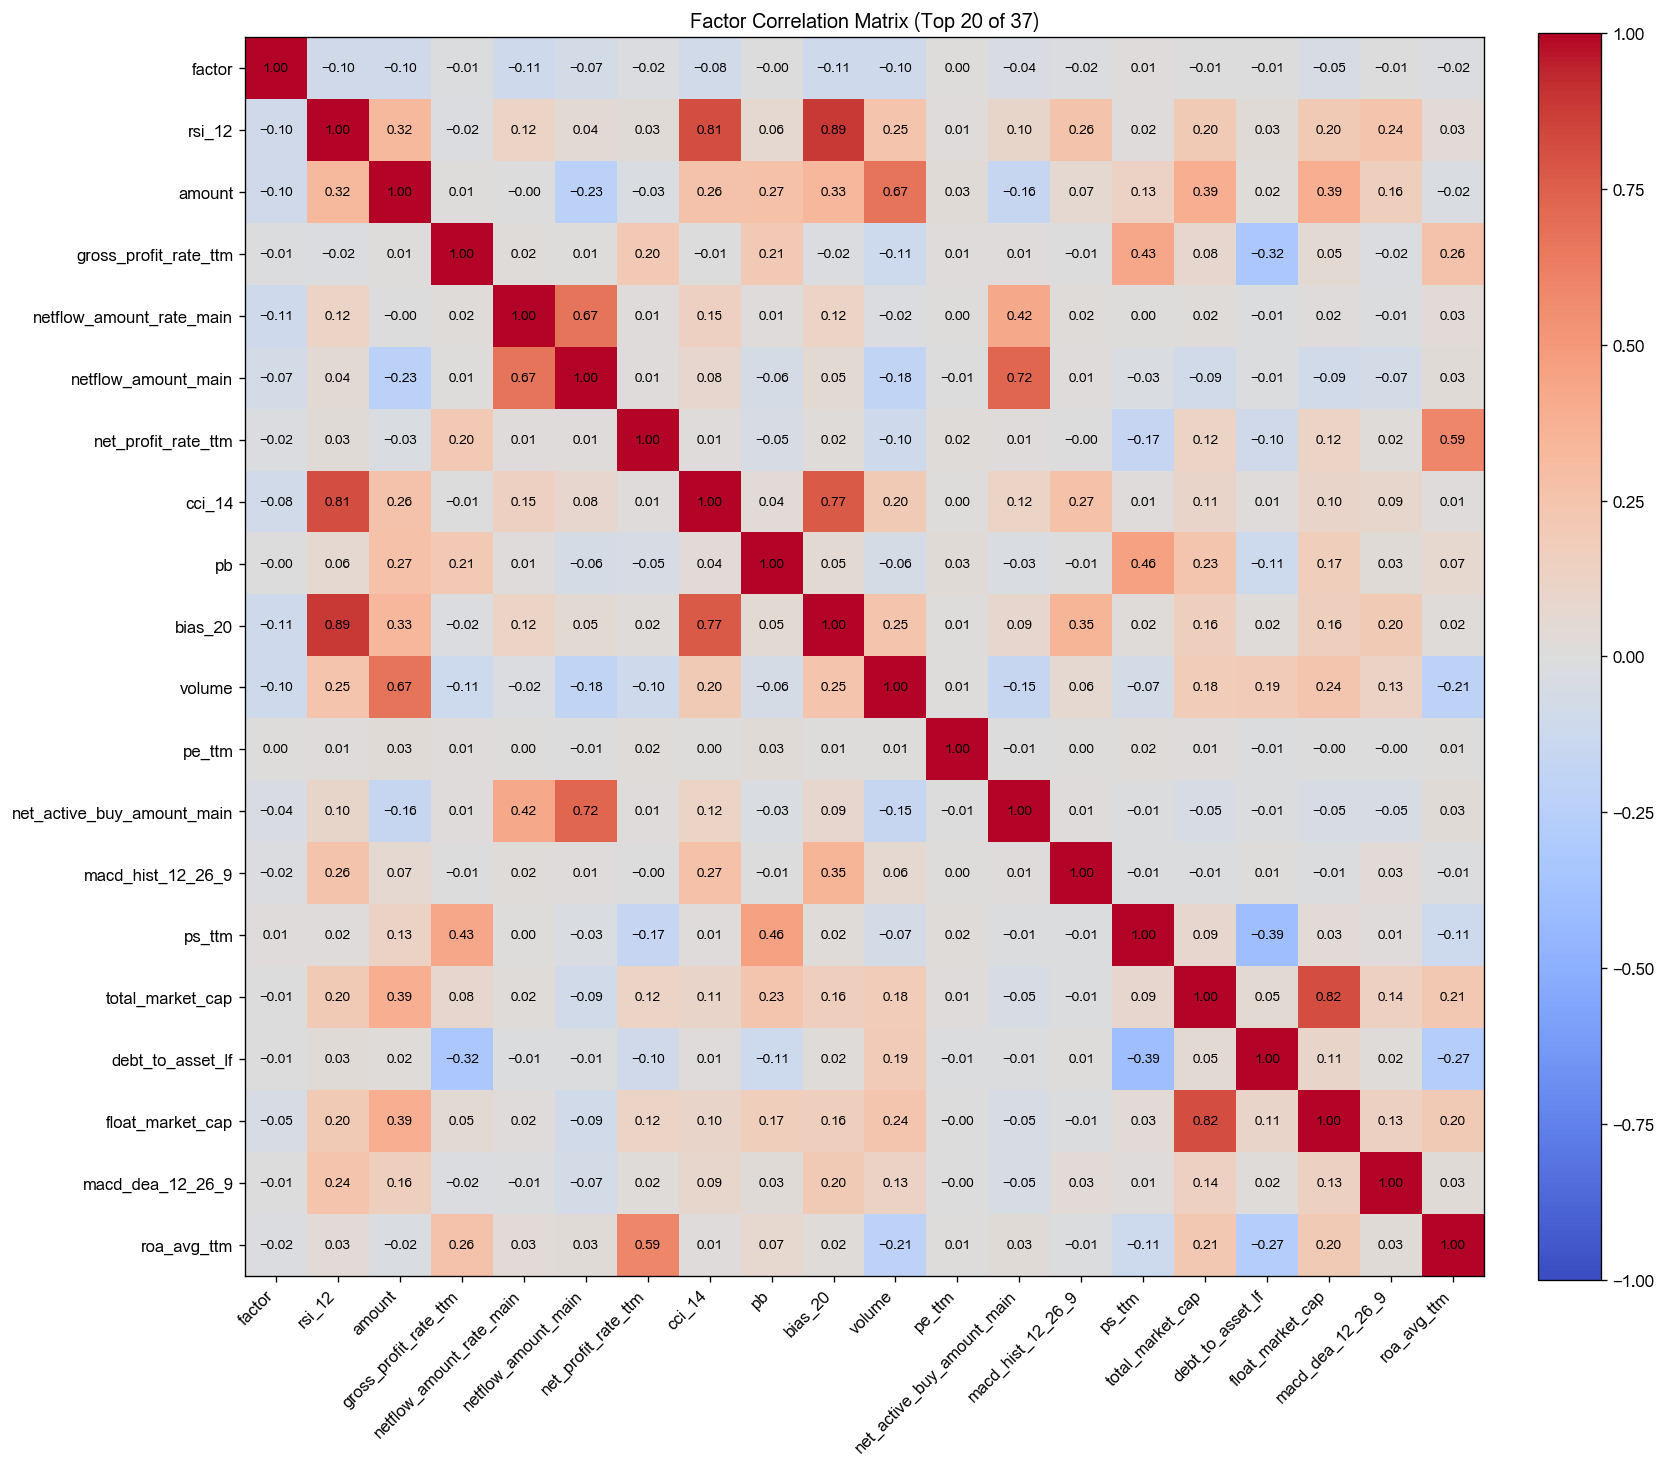

[2026-07-24 23:48:21] [warning  ] 返回的Outputs实例(size=34468463) 大于 64K, 将不会被缓存
[2026-07-24 23:48:21] [info     ] bigalpha_eval.v4 运行完成 [87.286s].
[2026-07-24 23:48:21] [info     ] local test V3_3_resid_label completed


In [2]:
def main(datasources, start_date, end_date):
    """
    BigAlpha 2026 AI factor - V3.3 residual-label rank-aligned XGBoost.

    This version trains on the part of next-day return ranks that cannot be
    explained by the official factor pool controls:
    1. No minute-level window function in SQL.
    2. Daily volume/amount use ARG_MAX because they are cumulative fields.
    3. One-year rolling training window by default.
    4. Daily cross-sectional ranked features and ranked next-day labels.
    5. Complete-date validation split with one-label-period purge.
    6. Residualize the training label against factor-pool controls by date.
    7. Residualize prediction again before output to improve Elastic Net
       ModelScore independence.
    """
    import gc
    import time
    import numpy as np
    import pandas as pd
    import dai
    import xgboost as xgb
    import structlog

    logger = structlog.get_logger()

    eval_start = pd.to_datetime(start_date)
    history_end = pd.Timestamp("2024-12-31")
    train_end_dt = min(history_end, eval_start - pd.Timedelta(days=1))
    train_start_dt = max(pd.Timestamp("2019-01-01"), train_end_dt - pd.Timedelta(days=365))
    train_start = train_start_dt.strftime("%Y-%m-%d")
    train_end = train_end_dt.strftime("%Y-%m-%d")

    fin_raw_cols = [
        "operating_revenue",
        "net_profit_to_parent_shareholders",
        "total_assets",
        "total_equity_to_parent_shareholders",
    ]

    def normalize_date_column(frame, col="date"):
        frame[col] = pd.to_datetime(frame[col]).astype("datetime64[ns]")
        return frame

    residual_control_cols = [
        "cci_14",
        "ps_ttm",
        "volume",
        "macd_hist_12_26_9",
        "rsi_12",
        "netflow_amount_main",
        "turn",
        "total_market_cap",
        "net_profit_rate_ttm",
        "netflow_amount_rate_main",
        "debt_to_asset_lf",
        "kdj_d_9_3_3",
        "beta_000300SH_22",
        "volatility_5",
        "net_active_buy_amount_main",
        "pe_ttm",
        "kdj_k_9_3_3",
        "pb",
        "momentum_5",
        "list_days",
    ]

    def rank_by_date(frame, value_col, out_col):
        frame[out_col] = (
            frame.groupby("date")[value_col].rank(method="average", pct=True) - 0.5
        )
        return frame

    def residualize_against_factor_pool(frame, sd, ed, raw_col="factor_raw"):
        t0 = time.time()
        keep_cols = ["date", "instrument", raw_col]
        out = frame[keep_cols].copy()
        out = normalize_date_column(out)
        out["instrument"] = out["instrument"].astype(str)

        select_cols = ", ".join(residual_control_cols)
        pool = dai.query(
            f"""
            SELECT date, instrument, {select_cols}
            FROM bigalpha_2026_factorlib
            """,
            filters={"date": [pd.to_datetime(sd), pd.to_datetime(ed)]},
        ).df()
        pool = normalize_date_column(pool)
        pool["instrument"] = pool["instrument"].astype(str)

        merged = pd.merge(out, pool, how="left", on=["date", "instrument"])
        del pool
        gc.collect()

        active_cols = []
        for col in residual_control_cols:
            if col not in merged:
                continue
            merged[col] = pd.to_numeric(merged[col], errors="coerce")
            merged[col] = merged[col].replace([np.inf, -np.inf], np.nan)
            ranked = (
                merged.groupby("date")[col]
                .rank(method="average", pct=True)
                .sub(0.5)
            )
            rank_col = f"{col}_pool_rank"
            merged[rank_col] = ranked
            active_cols.append(rank_col)

        def residualize_one_day(grp):
            y = pd.to_numeric(grp[raw_col], errors="coerce").to_numpy(dtype=float)
            valid_y = np.isfinite(y)
            if valid_y.sum() < 50 or not active_cols:
                grp["factor_residual"] = y
                return grp

            x = grp[active_cols].to_numpy(dtype=float)
            x = np.where(np.isfinite(x), x, 0.0)
            keep = np.nanstd(x, axis=0) > 1e-8
            if keep.sum() == 0:
                grp["factor_residual"] = y
                return grp

            x = x[:, keep]
            x = np.column_stack([np.ones(len(x)), x])
            xv = x[valid_y]
            yv = y[valid_y]
            ridge = np.eye(xv.shape[1]) * 1e-3
            ridge[0, 0] = 0.0
            try:
                beta = np.linalg.solve(xv.T @ xv + ridge, xv.T @ yv)
            except np.linalg.LinAlgError:
                beta = np.linalg.lstsq(xv, yv, rcond=None)[0]
            residual = y - x @ beta
            grp["factor_residual"] = residual
            return grp

        merged = merged.groupby("date", group_keys=False).apply(residualize_one_day)
        merged = rank_by_date(merged, "factor_residual", "factor_residual_rank")
        merged["factor"] = (
            0.35 * merged[raw_col] + 0.65 * merged["factor_residual_rank"]
        )
        merged = rank_by_date(merged, "factor", "factor")

        logger.info(
            "residualized against factor_pool rows=%d controls=%d t=%.1fs",
            len(merged),
            len(active_cols),
            time.time() - t0,
        )
        return merged[["date", "instrument", "factor", raw_col, "factor_residual_rank"]]

    def add_residual_label_against_factor_pool(frame, sd, ed):
        t0 = time.time()
        out = frame.copy()
        out = normalize_date_column(out)
        out["instrument"] = out["instrument"].astype(str)

        select_cols = ", ".join(residual_control_cols)
        pool = dai.query(
            f"""
            SELECT date, instrument, {select_cols}
            FROM bigalpha_2026_factorlib
            """,
            filters={"date": [pd.to_datetime(sd), pd.to_datetime(ed)]},
        ).df()
        pool = normalize_date_column(pool)
        pool["instrument"] = pool["instrument"].astype(str)

        merged = pd.merge(out, pool, how="left", on=["date", "instrument"])
        del pool
        gc.collect()

        active_cols = []
        for col in residual_control_cols:
            if col not in merged:
                continue
            merged[col] = pd.to_numeric(merged[col], errors="coerce")
            merged[col] = merged[col].replace([np.inf, -np.inf], np.nan)
            rank_col = f"{col}_pool_rank"
            merged[rank_col] = (
                merged.groupby("date")[col].rank(method="average", pct=True) - 0.5
            )
            active_cols.append(rank_col)

        def residualize_label_one_day(grp):
            y = pd.to_numeric(grp["label"], errors="coerce").to_numpy(dtype=float)
            valid_y = np.isfinite(y)
            if valid_y.sum() < 50 or not active_cols:
                grp["label_residual"] = y
                return grp

            x = grp[active_cols].to_numpy(dtype=float)
            x = np.where(np.isfinite(x), x, 0.0)
            keep = np.nanstd(x, axis=0) > 1e-8
            if keep.sum() == 0:
                grp["label_residual"] = y
                return grp

            x = x[:, keep]
            x = np.column_stack([np.ones(len(x)), x])
            xv = x[valid_y]
            yv = y[valid_y]
            ridge = np.eye(xv.shape[1]) * 1e-3
            ridge[0, 0] = 0.0
            try:
                beta = np.linalg.solve(xv.T @ xv + ridge, xv.T @ yv)
            except np.linalg.LinAlgError:
                beta = np.linalg.lstsq(xv, yv, rcond=None)[0]
            grp["label_residual"] = y - x @ beta
            return grp

        merged = merged.groupby("date", group_keys=False).apply(
            residualize_label_one_day
        )
        merged["label_residual"] = (
            merged.groupby("date")["label_residual"].rank(method="average", pct=True)
            - 0.5
        )
        logger.info(
            "residualized training label rows=%d controls=%d t=%.1fs",
            len(merged),
            len(active_cols),
            time.time() - t0,
        )
        drop_cols = residual_control_cols + active_cols
        return merged.drop(columns=[c for c in drop_cols if c in merged])

    def build_features(financial_table, bar1m_table, sd, ed, need_label=False):
        t0 = time.time()
        sd_dt = pd.to_datetime(sd)
        ed_dt = pd.to_datetime(ed)
        bar_start = sd_dt - pd.Timedelta(days=35)
        logger.info("build_features %s ~ %s need_label=%s", sd, ed, need_label)

        bar_sql = f"""
        WITH daily_agg AS (
            SELECT
                CAST(strftime(date, '%Y-%m-%d') AS DATETIME) AS date,
                instrument,
                ARG_MIN(open, date) AS open,
                MAX(high) AS high,
                MIN(low) AS low,
                ARG_MAX(close, date) AS close,
                ARG_MAX(pre_close, date) AS pre_close,
                ARG_MAX(volume, date) AS volume,
                ARG_MAX(amount, date) AS amount,
                (MAX(high) - MIN(low)) / NULLIF(ARG_MIN(open, date), 0)
                    AS intraday_range,
                (ARG_MAX(close, date) - MIN(low))
                    / NULLIF(MAX(high) - MIN(low), 0.0001)
                    AS close_position,
                AVG(
                    CASE
                        WHEN ask_price1 > 0 AND bid_price1 > 0 THEN
                            (ask_price1 - bid_price1)
                            / NULLIF((ask_price1 + bid_price1) / 2.0, 0)
                        ELSE NULL
                    END
                ) AS avg_spread,
                AVG(
                    CASE
                        WHEN ask_price1 > 0 AND bid_price1 > 0 THEN
                            (
                                COALESCE(bid_volume1, 0) * 1.0
                                + COALESCE(bid_volume2, 0) * 0.7
                                + COALESCE(bid_volume3, 0) * 0.5
                                + COALESCE(bid_volume4, 0) * 0.3
                                + COALESCE(bid_volume5, 0) * 0.1
                                - COALESCE(ask_volume1, 0) * 1.0
                                - COALESCE(ask_volume2, 0) * 0.7
                                - COALESCE(ask_volume3, 0) * 0.5
                                - COALESCE(ask_volume4, 0) * 0.3
                                - COALESCE(ask_volume5, 0) * 0.1
                            )
                            / NULLIF(
                                COALESCE(bid_volume1, 0) * 1.0
                                + COALESCE(bid_volume2, 0) * 0.7
                                + COALESCE(bid_volume3, 0) * 0.5
                                + COALESCE(bid_volume4, 0) * 0.3
                                + COALESCE(bid_volume5, 0) * 0.1
                                + COALESCE(ask_volume1, 0) * 1.0
                                + COALESCE(ask_volume2, 0) * 0.7
                                + COALESCE(ask_volume3, 0) * 0.5
                                + COALESCE(ask_volume4, 0) * 0.3
                                + COALESCE(ask_volume5, 0) * 0.1,
                                0
                            )
                        ELSE NULL
                    END
                ) AS orderbook_imbalance,
                AVG(
                    CASE
                        WHEN EXTRACT(hour FROM date) * 60 + EXTRACT(minute FROM date)
                             BETWEEN 570 AND 600
                             AND ask_price1 > 0 AND bid_price1 > 0 THEN
                            (
                                COALESCE(bid_volume1, 0) + COALESCE(bid_volume2, 0)
                                - COALESCE(ask_volume1, 0) - COALESCE(ask_volume2, 0)
                            )
                            / NULLIF(
                                COALESCE(bid_volume1, 0) + COALESCE(bid_volume2, 0)
                                + COALESCE(ask_volume1, 0) + COALESCE(ask_volume2, 0),
                                0
                            )
                        ELSE NULL
                    END
                ) AS open_orderbook_imbalance,
                AVG(
                    CASE
                        WHEN EXTRACT(hour FROM date) * 60 + EXTRACT(minute FROM date)
                             BETWEEN 870 AND 897
                             AND ask_price1 > 0 AND bid_price1 > 0 THEN
                            (
                                COALESCE(bid_volume1, 0) + COALESCE(bid_volume2, 0)
                                - COALESCE(ask_volume1, 0) - COALESCE(ask_volume2, 0)
                            )
                            / NULLIF(
                                COALESCE(bid_volume1, 0) + COALESCE(bid_volume2, 0)
                                + COALESCE(ask_volume1, 0) + COALESCE(ask_volume2, 0),
                                0
                            )
                        ELSE NULL
                    END
                ) AS tail_orderbook_imbalance,
                STDDEV_SAMP(close) / NULLIF(AVG(close), 0)
                    AS intraday_dispersion,
                COUNT(*) AS bar_count,
                SUM(
                    CASE WHEN ask_price1 > 0 AND bid_price1 > 0 THEN 1 ELSE 0 END
                ) AS valid_quote_count
            FROM {bar1m_table}
            WHERE close > 0
            GROUP BY strftime(date, '%Y-%m-%d'), instrument
        )
        SELECT
            *,
            tail_orderbook_imbalance - open_orderbook_imbalance
                AS orderbook_migration,
            close / NULLIF(amount / NULLIF(volume, 0), 0) - 1
                AS close_to_vwap,
            intraday_range / NULLIF(amount, 0) * 1e8
                AS amihud_proxy,
            valid_quote_count * 1.0 / NULLIF(bar_count, 0)
                AS valid_quote_ratio
        FROM daily_agg
        WHERE bar_count >= 30
        ORDER BY instrument, date
        """

        bar = dai.query(
            bar_sql,
            filters={"date": [bar_start, ed_dt]},
            compression=True,
        ).df()
        bar = normalize_date_column(bar)
        bar["instrument"] = bar["instrument"].astype(str)

        numeric_bar_cols = [
            "open",
            "high",
            "low",
            "close",
            "pre_close",
            "volume",
            "amount",
            "intraday_range",
            "close_position",
            "avg_spread",
            "orderbook_imbalance",
            "open_orderbook_imbalance",
            "tail_orderbook_imbalance",
            "orderbook_migration",
            "intraday_dispersion",
            "close_to_vwap",
            "amihud_proxy",
            "valid_quote_ratio",
        ]
        for col in numeric_bar_cols:
            bar[col] = pd.to_numeric(bar[col], errors="coerce")

        bar = bar.sort_values(["instrument", "date"]).reset_index(drop=True)
        g = bar.groupby("instrument", group_keys=False)
        bar["ret_1d"] = g["close"].pct_change()
        for n in [5, 10, 20]:
            bar[f"momentum_{n}d"] = bar["close"] / g["close"].shift(n) - 1
        bar["reversal_1d"] = -bar["ret_1d"]
        bar["reversal_5d"] = -bar["momentum_5d"]

        for n in [5, 20]:
            bar[f"volatility_{n}d"] = g["ret_1d"].transform(
                lambda x: x.rolling(n, min_periods=3).std()
            )
            prior_volume = g["volume"].transform(
                lambda x: x.shift(1).rolling(n, min_periods=3).mean()
            )
            bar[f"volume_ratio_{n}d"] = bar["volume"] / (prior_volume + 1) - 1

        prior_amount = g["amount"].transform(
            lambda x: x.shift(1).rolling(20, min_periods=3).mean()
        )
        bar["amount_ratio_20d"] = bar["amount"] / (prior_amount + 1) - 1

        prior_spread = g["avg_spread"].transform(
            lambda x: x.shift(1).rolling(20, min_periods=5).median()
        )
        bar["spread_relative_20d"] = bar["avg_spread"] / (prior_spread.abs() + 1e-8) - 1

        prior_obi = g["orderbook_imbalance"].transform(
            lambda x: x.shift(1).rolling(20, min_periods=5).mean()
        )
        bar["obi_change_20d"] = bar["orderbook_imbalance"] - prior_obi

        if need_label:
            bar["next_date"] = g["date"].shift(-1)
            bar["raw_label"] = g["close"].shift(-1) / bar["close"] - 1

        logger.info("bar features rows=%d t=%.1fs", len(bar), time.time() - t0)

        fin_start = sd_dt - pd.Timedelta(days=400)
        fin_select = ", ".join(fin_raw_cols)
        fin = dai.query(
            f"""
            SELECT date, instrument, {fin_select}
            FROM {financial_table}
            WHERE category='lf' AND shift=0
            """,
            filters={"date": [fin_start, ed_dt]},
        ).df()
        fin = normalize_date_column(fin)
        fin["instrument"] = fin["instrument"].astype(str)
        fin = (
            fin.sort_values(["instrument", "date"])
            .drop_duplicates(["instrument", "date"], keep="last")
        )

        fin["roe_proxy"] = (
            fin["net_profit_to_parent_shareholders"]
            / fin["total_equity_to_parent_shareholders"].replace(0, np.nan)
        )
        fin["asset_turnover"] = (
            fin["operating_revenue"]
            / fin["total_assets"].replace(0, np.nan)
        )
        fin["profit_margin"] = (
            fin["net_profit_to_parent_shareholders"]
            / fin["operating_revenue"].replace(0, np.nan)
        )
        fin["leverage"] = (
            fin["total_assets"]
            / fin["total_equity_to_parent_shareholders"].replace(0, np.nan)
        )
        fin["log_assets"] = np.log(fin["total_assets"].abs().replace(0, np.nan) + 1)
        fin_derived = [
            "roe_proxy",
            "asset_turnover",
            "profit_margin",
            "leverage",
            "log_assets",
        ]

        df = bar[(bar["date"] >= sd_dt) & (bar["date"] <= ed_dt)].copy()
        df = normalize_date_column(df)
        del bar
        gc.collect()

        merge_parts = []
        fin_by_instrument = {
            inst: normalize_date_column(grp[["date"] + fin_derived].copy()).sort_values("date")
            for inst, grp in fin.groupby("instrument", sort=False)
        }
        for instrument, grp in df.groupby("instrument", sort=False):
            left = normalize_date_column(grp.copy()).sort_values("date")
            right = fin_by_instrument.get(instrument)
            if right is None or right.empty:
                for col in fin_derived:
                    left[col] = np.nan
                merge_parts.append(left)
            else:
                merged = pd.merge_asof(
                    left,
                    right,
                    on="date",
                    direction="backward",
                )
                merge_parts.append(merged)
        df = pd.concat(merge_parts, ignore_index=True)
        del fin, fin_by_instrument, merge_parts
        gc.collect()

        stock_pool = dai.query(
            "SELECT date, instrument FROM bigalpha_2026_instruments",
            filters={"date": [sd_dt, ed_dt]},
        ).df()
        stock_pool = normalize_date_column(stock_pool)
        stock_pool["instrument"] = stock_pool["instrument"].astype(str)
        df["instrument"] = df["instrument"].astype(str)
        df = pd.merge(
            df,
            stock_pool.drop_duplicates(["date", "instrument"]),
            how="inner",
            on=["date", "instrument"],
        )

        base_feature_cols = [
            "close",
            "volume",
            "amount",
            "intraday_range",
            "close_position",
            "avg_spread",
            "orderbook_imbalance",
            "tail_orderbook_imbalance",
            "orderbook_migration",
            "intraday_dispersion",
            "close_to_vwap",
            "amihud_proxy",
            "valid_quote_ratio",
            "ret_1d",
            "momentum_5d",
            "momentum_10d",
            "momentum_20d",
            "reversal_1d",
            "reversal_5d",
            "volatility_5d",
            "volatility_20d",
            "volume_ratio_5d",
            "volume_ratio_20d",
            "amount_ratio_20d",
            "spread_relative_20d",
            "obi_change_20d",
        ] + fin_derived

        for col in base_feature_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)

        feature_cols = [f"{col}_rank" for col in base_feature_cols]
        ranked_features = (
            df.groupby("date")[base_feature_cols]
            .rank(method="average", pct=True)
            .sub(0.5)
        )
        ranked_features.columns = feature_cols
        df = pd.concat([df, ranked_features], axis=1)
        del ranked_features
        gc.collect()

        if need_label:
            calendar_dates = sorted(stock_pool["date"].dropna().unique())
            next_date_map = {
                pd.Timestamp(calendar_dates[i]): pd.Timestamp(calendar_dates[i + 1])
                for i in range(len(calendar_dates) - 1)
            }
            df["expected_next_date"] = df["date"].map(next_date_map)
            df.loc[df["next_date"] != df["expected_next_date"], "raw_label"] = np.nan
            df["raw_label"] = df["raw_label"].replace([np.inf, -np.inf], np.nan)
            df["label"] = (
                df.groupby("date")["raw_label"].rank(method="average", pct=True) - 0.5
            )

        logger.info(
            "features done rows=%d features=%d t=%.1fs",
            len(df),
            len(feature_cols),
            time.time() - t0,
        )
        return df.reset_index(drop=True), feature_cols

    logger.info("training window: %s ~ %s", train_start, train_end)
    train_df, feature_cols = build_features(
        "bigalpha_2026_financial",
        "bigalpha_2026_stock_bar1m",
        train_start,
        train_end,
        need_label=True,
    )
    train_df = train_df.dropna(subset=["label", "next_date"])

    unique_dates = np.array(sorted(train_df["date"].unique()))
    if len(unique_dates) < 120:
        raise ValueError("Not enough complete training dates for V3.3")

    validation_dates = min(50, max(30, len(unique_dates) // 5))
    valid_start = pd.Timestamp(unique_dates[-validation_dates])
    train_mask = (
        (train_df["date"] < valid_start)
        & (train_df["next_date"] < valid_start)
    )
    valid_mask = train_df["date"] >= valid_start

    train_df = add_residual_label_against_factor_pool(train_df, train_start, train_end)
    train_df = train_df.dropna(subset=["label_residual"])
    train_mask = (
        (train_df["date"] < valid_start)
        & (train_df["next_date"] < valid_start)
    )
    valid_mask = train_df["date"] >= valid_start
    fit_df = train_df.loc[train_mask].sort_values(["date", "instrument"])
    valid_df = train_df.loc[valid_mask].sort_values(["date", "instrument"])

    logger.info(
        "fit rows=%d valid rows=%d valid_start=%s features=%d",
        len(fit_df),
        len(valid_df),
        valid_start.strftime("%Y-%m-%d"),
        len(feature_cols),
    )

    model = xgb.XGBRegressor(
        n_estimators=160,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=35,
        reg_lambda=10.0,
        reg_alpha=1.5,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=25,
    )
    model.fit(
        fit_df[feature_cols],
        fit_df["label_residual"],
        eval_set=[(valid_df[feature_cols], valid_df["label_residual"])],
        verbose=False,
    )

    valid_eval = valid_df[["date", "label", "label_residual"]].copy()
    valid_eval["prediction"] = model.predict(valid_df[feature_cols])

    def calculate_daily_ic(grp, label_col="label"):
        if grp["prediction"].nunique() < 2 or grp[label_col].nunique() < 2:
            return np.nan
        return grp["prediction"].rank().corr(grp[label_col].rank())

    valid_ic = valid_eval.groupby("date").apply(calculate_daily_ic).dropna()
    ic_mean = valid_ic.mean()
    ic_std = valid_ic.std()
    ic_ir = ic_mean / ic_std if ic_std and not np.isnan(ic_std) else np.nan
    valid_resid_target_ic = (
        valid_eval.groupby("date")
        .apply(lambda grp: calculate_daily_ic(grp, label_col="label_residual"))
        .dropna()
    )
    target_ic_mean = valid_resid_target_ic.mean()
    target_ic_std = valid_resid_target_ic.std()
    target_ic_ir = (
        target_ic_mean / target_ic_std
        if target_ic_std and not np.isnan(target_ic_std)
        else np.nan
    )
    logger.info(
        "model done best_iteration=%s raw_label_ic_mean=%.6f raw_label_ic_ir=%.4f residual_label_ic_mean=%.6f residual_label_ic_ir=%.4f",
        getattr(model, "best_iteration", None),
        ic_mean,
        ic_ir,
        target_ic_mean,
        target_ic_ir,
    )

    valid_factor = valid_df[["date", "instrument"]].copy()
    valid_factor["factor_raw"] = (
        valid_eval.groupby("date")["prediction"].rank(method="average", pct=True)
        - 0.5
    )
    valid_factor = residualize_against_factor_pool(
        valid_factor,
        valid_start.strftime("%Y-%m-%d"),
        train_end,
        raw_col="factor_raw",
    )
    valid_resid_eval = pd.merge(
        valid_factor[["date", "instrument", "factor"]],
        valid_df[["date", "instrument", "label"]],
        how="inner",
        on=["date", "instrument"],
    ).rename(columns={"factor": "prediction"})
    valid_resid_ic = valid_resid_eval.groupby("date").apply(calculate_daily_ic).dropna()
    resid_ic_mean = valid_resid_ic.mean()
    resid_ic_std = valid_resid_ic.std()
    resid_ic_ir = (
        resid_ic_mean / resid_ic_std
        if resid_ic_std and not np.isnan(resid_ic_std)
        else np.nan
    )
    logger.info(
        "residual valid_ic_mean=%.6f valid_ic_ir=%.4f",
        resid_ic_mean,
        resid_ic_ir,
    )

    del fit_df, valid_df, valid_eval, valid_ic, valid_resid_target_ic, valid_factor
    del valid_resid_eval, valid_resid_ic, train_df
    gc.collect()

    test_df, _ = build_features(
        datasources["financial"],
        datasources["bar1m"],
        start_date,
        end_date,
        need_label=False,
    )
    test_df["prediction"] = model.predict(test_df[feature_cols])
    test_df["factor_raw"] = (
        test_df.groupby("date")["prediction"].rank(method="average", pct=True) - 0.5
    )
    result = residualize_against_factor_pool(
        test_df[["date", "instrument", "factor_raw"]],
        start_date,
        end_date,
        raw_col="factor_raw",
    )
    result["factor"] = result["factor"].replace([np.inf, -np.inf], np.nan)
    result = result.dropna(subset=["factor"])
    result = result.drop_duplicates(["date", "instrument"], keep="last")
    logger.info(
        "return factor rows=%d days=%d stocks=%d",
        len(result),
        result["date"].nunique(),
        result["instrument"].nunique(),
    )
    return result.reset_index(drop=True)[["date", "instrument", "factor"]]


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()
    datasources = {
        "financial": "bigalpha_2026_financial",
        "bar1m": "bigalpha_2026_stock_bar1m",
    }

    # First run a lighter smoke test. After it succeeds, change this to
    # 2024-01-01 ~ 2024-12-31 for the full local comparison.
    start_date = "2024-01-01"
    end_date = "2024-12-31"

    logger.info("local test V3_3_resid_label %s ~ %s", start_date, end_date)
    factor_data = main(datasources, start_date, end_date)
    logger.info(
        "factor_data rows=%d days=%d stocks=%d",
        len(factor_data),
        factor_data["date"].nunique(),
        factor_data["instrument"].nunique(),
    )

    logger.info("loading official factor pool")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
    logger.info("local test V3_3_resid_label completed")